# TimesFM — Model Experiment
**Dataset:** Monthly Labor Market (`monthly_labor_market.csv`)  
**Target:** `EMPLOY`  
**Horizon:** 12 months  
**Split:** 80 % train / last 12 months test  
**Metric:** MAE  
**Model:** TimesFM (pretrained — `google/timesfm-1.0-200m`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

## 1. Load & Preprocess Data

In [2]:
df = pd.read_csv("../data/processed/monthly_labor_market.csv")

df.rename(columns={"date": "ds"}, inplace=True)
df["ds"] = pd.to_datetime(df["ds"], format="%Y:%m")

df = df.dropna(how="all", subset=df.columns[1:])
df = df.ffill()
df = df.dropna()

df.head()

,ds,POP,LFC,LFPART,RUC,EMPLOY,H,HG,HS
300,1964-01-01,123560.0,72356.0,58.5594,5.6,57487.0,50.8,92.4,39.3
301,1964-02-01,123707.0,72683.0,58.7542,5.4,57753.0,51.5,95.3,39.4
302,1964-03-01,123857.0,72713.0,58.7072,5.4,57897.0,51.5,95.1,39.4
303,1964-04-01,124019.0,73274.0,59.0829,5.3,57922.0,51.7,95.2,39.6
304,1964-05-01,124204.0,73395.0,59.0923,5.1,58089.0,51.9,95.6,39.6


## 2. Train / Test Split

In [3]:
TARGET = "EMPLOY"
HORIZON = 12

split = int(len(df) * 0.8)

train_df = df.iloc[:split]
test_df  = df.iloc[split:split + HORIZON]

y_true = test_df[TARGET].values

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (596, 9)
Test shape:  (12, 9)


## 3. Load Pretrained TimesFM

In [4]:
# pip install timesfm
import timesfm

tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        backend="gpu",          # change to "cpu" if no GPU
        per_core_batch_size=32,
        horizon_len=HORIZON,
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
    ),
)

print("TimesFM loaded.")

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.11.0 (main, Mar  1 2023, 12:33:14) [Clang 14.0.6 ].


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

TimesFM loaded.


## 4. Forecast (zero-shot)

In [5]:
# TimesFM expects a list of 1-D numpy arrays
context = [train_df[TARGET].values.astype(np.float32)]

# frequency_input: 0 = default / unknown, 1 = per-second … use 0 for monthly
point_forecast, _ = tfm.forecast(
    inputs=context,
    freq=[0],
)

# Returns shape (n_series, horizon); grab first series
timesfm_pred = point_forecast[0][:HORIZON]

print("Shape:     ", timesfm_pred.shape)
print("Prediction:", timesfm_pred)

Shape:      (12,)
Prediction: [136287.66 136369.25 136937.88 137119.84 137485.6  137739.48 138136.56
 138135.72 138516.33 138932.48 139143.95 139220.19]


## 5. Evaluate — MAE

In [6]:
mae_timesfm = mean_absolute_error(y_true, timesfm_pred)
print(f"TimesFM MAE: {mae_timesfm:.4f}")

TimesFM MAE: 205.0573


## 6. Plot Forecast vs Actual

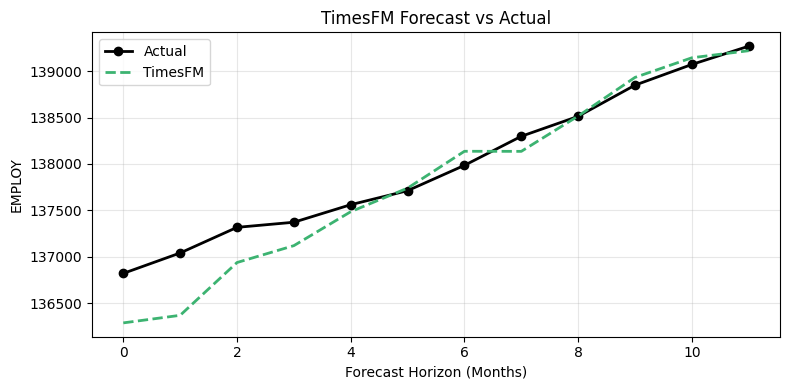


Final MAE — TimesFM: 205.0573


In [7]:
t = range(HORIZON)

plt.figure(figsize=(8, 4))

plt.plot(t, y_true,
         color="black", marker="o", label="Actual", linewidth=2)

plt.plot(t, timesfm_pred,
         color="mediumseagreen", linestyle="--", label="TimesFM", linewidth=2)

plt.legend()
plt.title("TimesFM Forecast vs Actual")
plt.xlabel("Forecast Horizon (Months)")
plt.ylabel(TARGET)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFinal MAE — TimesFM: {mae_timesfm:.4f}")